# Eksperimen SGD vs Adam (Tugas Hari 6 - Anggota A)
Notebook ini membandingkan optimizer SGD dan Adam pada FFNN from scratch dengan arsitektur, data, dan hyperparameter dasar yang sama.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

sys.path.append(str(Path().resolve().parent))

from data_prep import load_and_preprocess_data
from ffnn import FFNN

In [2]:
np.random.seed(42)

data_path = Path.cwd().parent.parent / 'data' / 'global_student_placement_and_salary.csv'
X_train, y_train_raw, X_val, y_val_raw = load_and_preprocess_data(str(data_path))

num_classes = len(np.unique(y_train_raw))
is_binary = num_classes == 2

if is_binary:
    y_train = y_train_raw.reshape(-1, 1).astype(np.float64)
    y_val = y_val_raw.reshape(-1, 1).astype(np.float64)
    output_size = 1
    output_activation = 'sigmoid'
    loss_type = 'binary_crossentropy'
else:
    y_train = np.eye(num_classes)[y_train_raw]
    y_val = np.eye(num_classes)[y_val_raw]
    output_size = num_classes
    output_activation = 'softmax'
    loss_type = 'categorical_crossentropy'

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('num_classes =', num_classes, '| binary =', is_binary)

Train: (8000, 11) (8000, 1)
Val  : (2000, 11) (2000, 1)
num_classes = 2 | binary = True


In [3]:
def predict_labels(model, X, is_binary_model):
    y_pred = model.forward(X)
    if is_binary_model:
        return (y_pred >= 0.5).astype(int).reshape(-1)
    return np.argmax(y_pred, axis=1)

def run_optimizer_experiment(optimizer_name, X_train, y_train, X_val, y_val, y_val_raw, output_size, output_activation, loss_type, is_binary, epochs=60, batch_size=32, learning_rate=0.01):
    model = FFNN(
        layer_numbers_list=[X_train.shape[1], 16, 16, output_size],
        activation_function_list=['relu', 'relu', output_activation],
        weight_initial='he',
    )

    history = model.fit(
        X=X_train,
        y=y_train,
        X_val=X_val,
        y_val=y_val,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=0,
        loss_type=loss_type,
        reg_type=None,
        lambda_=0.0,
        optimizer=optimizer_name,
        beta1=0.9,
        beta2=0.999,
        adam_eps=1e-8,
    )

    y_val_pred = predict_labels(model, X_val, is_binary)
    val_acc = accuracy_score(y_val_raw, y_val_pred)

    return {
        'optimizer': optimizer_name,
        'history': history,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_val_accuracy': val_acc,
        'model': model,
    }

## Konfigurasi Eksperimen
Kedua optimizer memakai setup yang sama agar perbandingan adil.

In [4]:
optimizers = ['sgd', 'adam']
epochs = 60
batch_size = 32
learning_rate = 0.01

print('optimizers =', optimizers)
print('epochs =', epochs)
print('batch_size =', batch_size)
print('learning_rate =', learning_rate)
print('weight_init = he')

optimizers = ['sgd', 'adam']
epochs = 60
batch_size = 32
learning_rate = 0.01
weight_init = he


In [5]:
results = {}
for optimizer_name in optimizers:
    results[optimizer_name] = run_optimizer_experiment(
        optimizer_name=optimizer_name,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        y_val_raw=y_val_raw,
        output_size=output_size,
        output_activation=output_activation,
        loss_type=loss_type,
        is_binary=is_binary,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
    )

print('Training selesai untuk SGD dan Adam.')

Training selesai untuk SGD dan Adam.


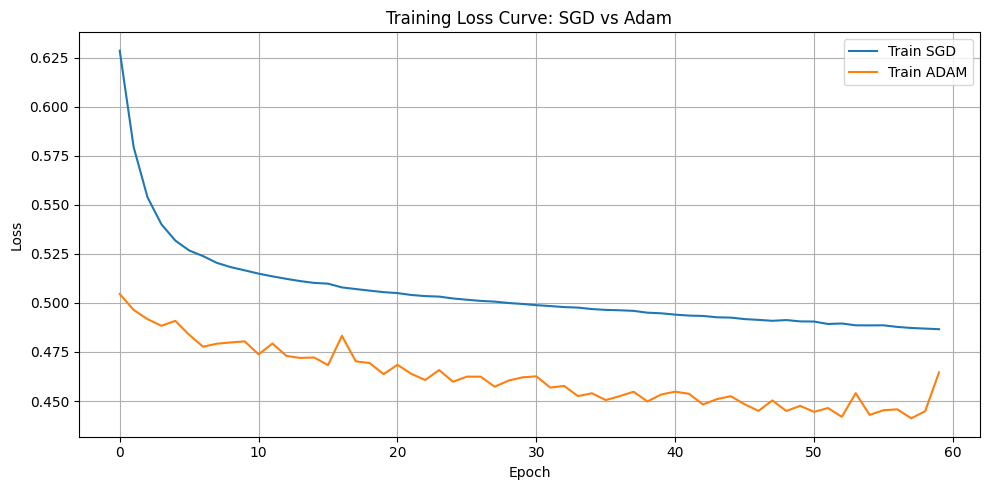

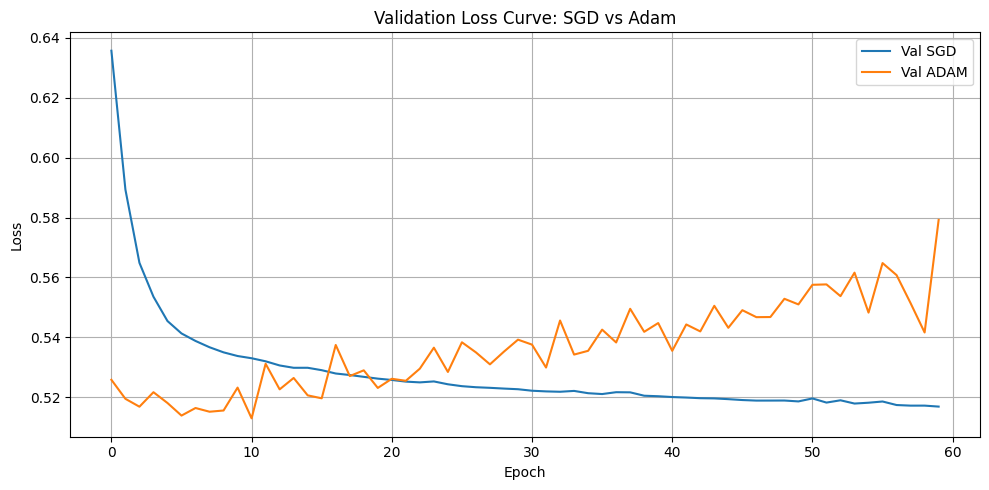

In [6]:
plt.figure(figsize=(10, 5))
for optimizer_name in optimizers:
    plt.plot(results[optimizer_name]['history']['train_loss'], label=f'Train {optimizer_name.upper()}')

plt.title('Training Loss Curve: SGD vs Adam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for optimizer_name in optimizers:
    plt.plot(results[optimizer_name]['history']['val_loss'], label=f'Val {optimizer_name.upper()}')

plt.title('Validation Loss Curve: SGD vs Adam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
print('Ringkasan metrik akhir')
print('optimizer | final_train_loss | final_val_loss | final_val_accuracy')
for optimizer_name in optimizers:
    r = results[optimizer_name]
    print(f"{optimizer_name:>9} | {r['final_train_loss']:.6f} | {r['final_val_loss']:.6f} | {r['final_val_accuracy']:.6f}")

best_by_acc = max(optimizers, key=lambda x: results[x]['final_val_accuracy'])
best_by_val_loss = min(optimizers, key=lambda x: results[x]['final_val_loss'])

print('')
print('Best by validation accuracy:', best_by_acc.upper())
print('Best by validation loss    :', best_by_val_loss.upper())

Ringkasan metrik akhir
optimizer | final_train_loss | final_val_loss | final_val_accuracy
      sgd | 0.486624 | 0.516921 | 0.727000
     adam | 0.464612 | 0.579209 | 0.733500

Best by validation accuracy: ADAM
Best by validation loss    : SGD



=== Distribusi Bobot dan Gradien: SGD ===


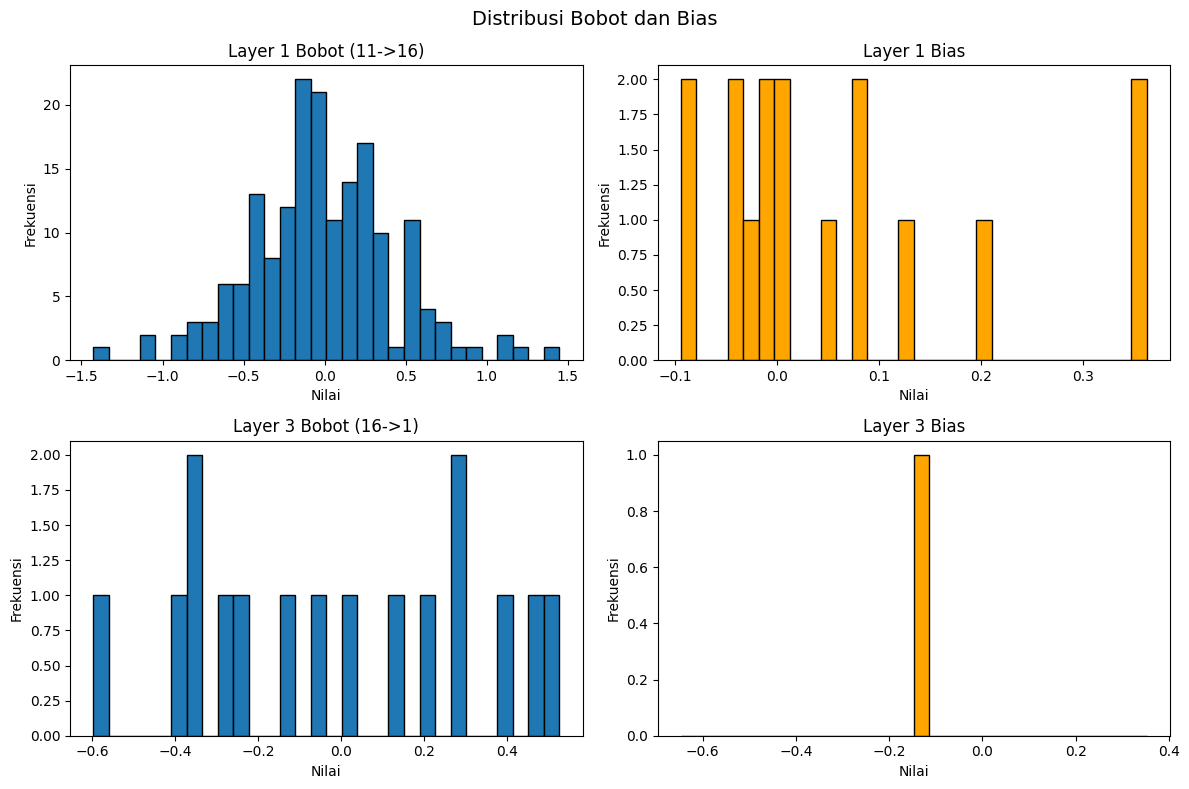

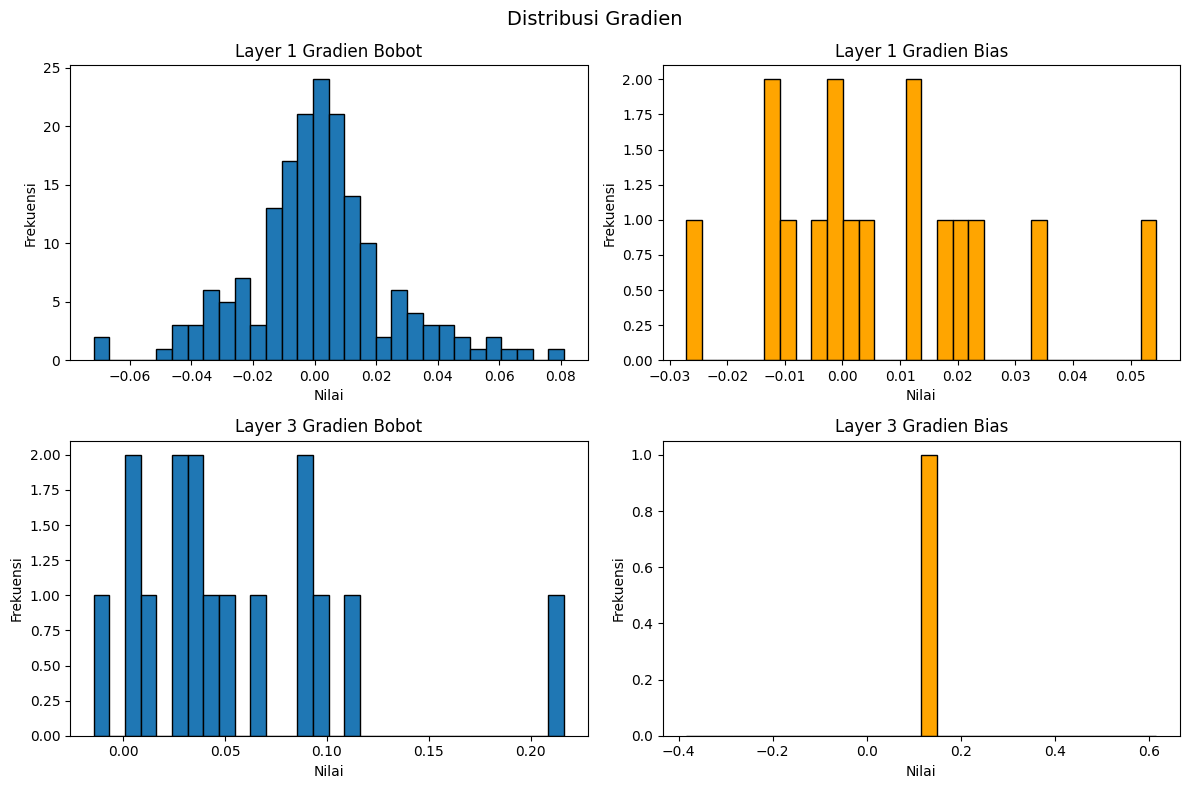


=== Distribusi Bobot dan Gradien: ADAM ===


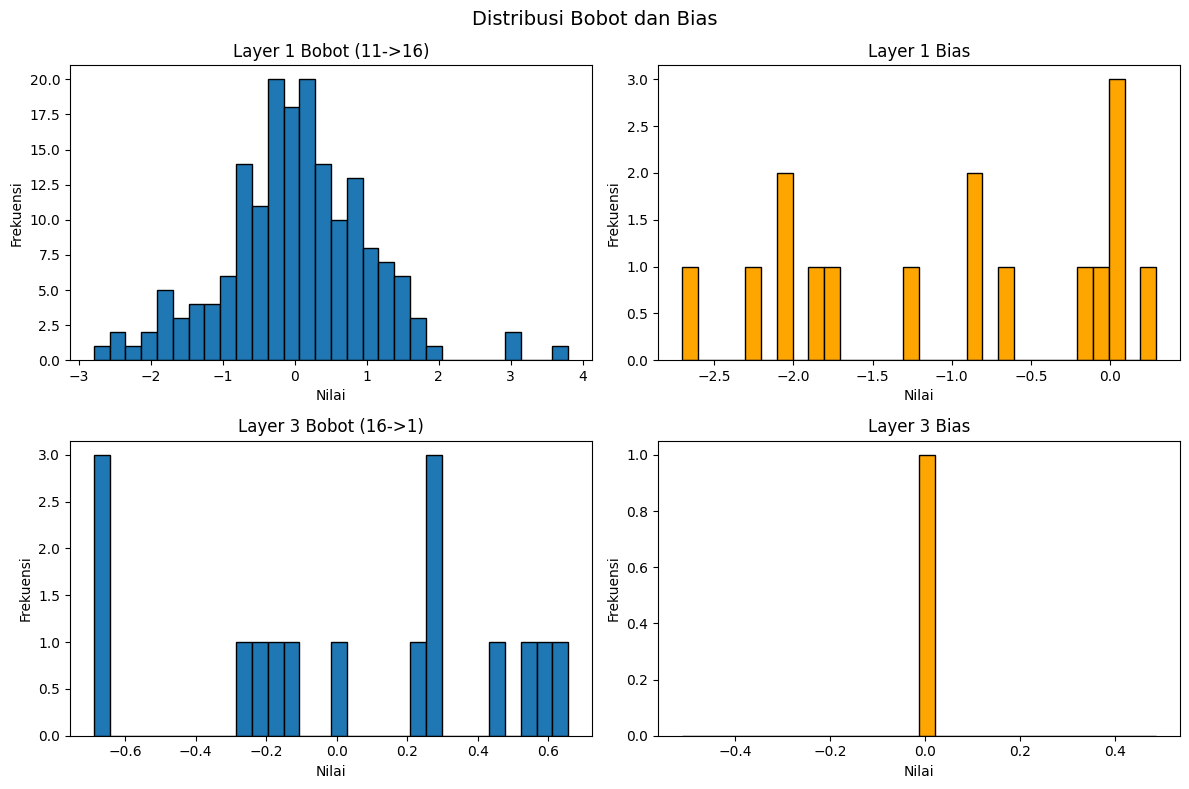

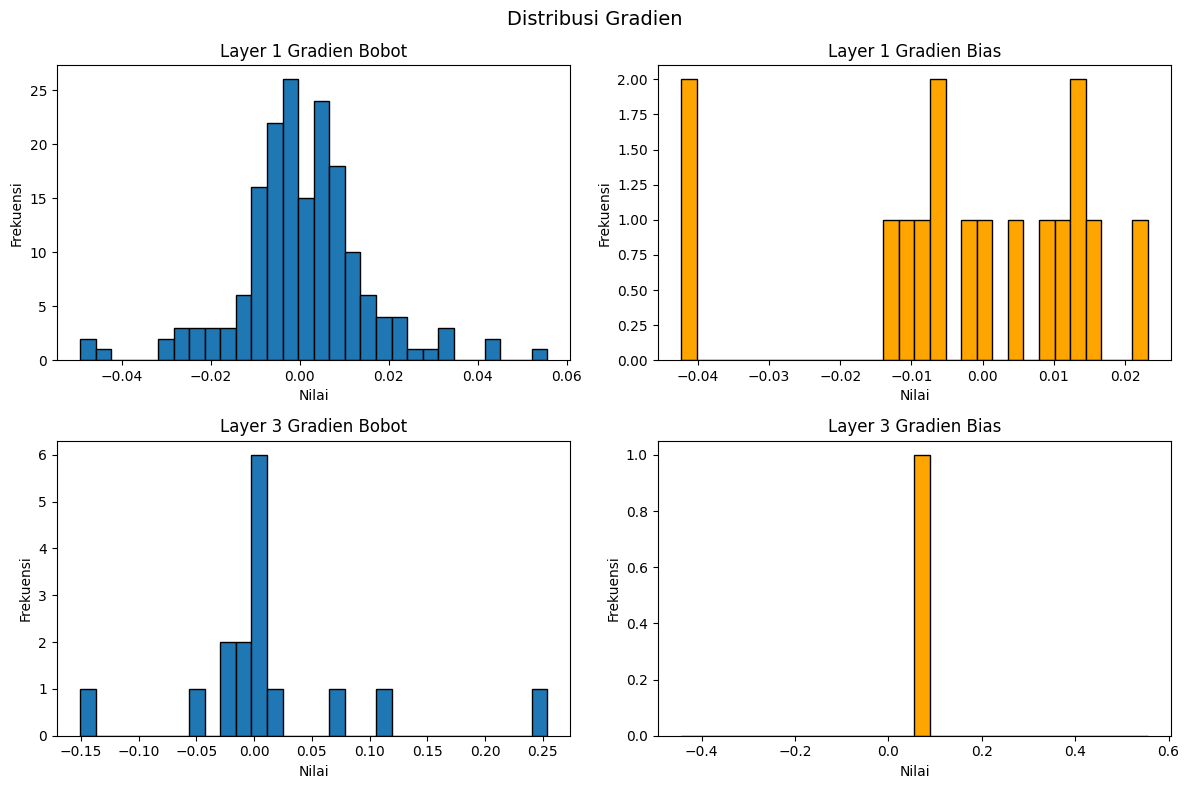

In [8]:
for optimizer_name in optimizers:
    print(f'\n=== Distribusi Bobot dan Gradien: {optimizer_name.upper()} ===')
    model = results[optimizer_name]['model']
    selected_layers = [0, len(model.weights) - 1] if len(model.weights) > 1 else [0]
    model.plot_weight_distribution(layers=selected_layers)
    model.plot_gradient_distribution(layers=selected_layers)